# Team T - LSTM Draft Notebook (Data-Only, Notebook-Only Scope)

## Project Draft Scope
This notebook is the draft technical study for Team T's quantitative trading project replication effort.

**Team Members and Student IDs**
- Utsav Thakur — `0000000`
- Bailey Meche — `0000000`
- Madhav Fadadu — `0000000`
- Mohamed Zakaria — `0000000`
- Vidhi Jain — `0000000`

**Deliverable note**
- This draft intentionally focuses on the notebook artifact only.
- Pitchbook content is deferred for a later pass.
- This draft is data-focused: no model training, backtest, or performance analysis is included.


## Research Motivation, Replication Framing, and Data Design

### Project idea and rationale
We are building a point-in-time equity feature panel motivated by the replication workflow for our quantitative strategy project. The immediate draft goal is to construct clean, auditable inputs for later strategy modeling and simulation. We use fundamental accounting and ratio data from Zacks (via Nasdaq Data Link API) and daily equity price data from a local historical file.

### Why this draft is data-first
For this submission stage, we prioritize reproducible data assembly and feature integrity over return analysis. A reliable panel is a prerequisite for credible downstream experiments (signal construction, portfolio rules, and risk controls).

### Data sources used in this notebook
- `ZACKS/MT` for ticker metadata and S&P 500 membership proxy.
- `ZACKS/MKTV` for market value ranking to define a deterministic universe.
- `ZACKS/FR` and `ZACKS/FC` for quarterly fundamentals.
- Local daily prices from `PRICES_20241105.csv` for 2006-2013 equity time series.

### Point-in-time philosophy (no-lookahead)
Quarterly fundamentals are not assumed available on their period-end date. Instead, each record is shifted by a fixed availability lag (`per_end_date + 45 days`). Daily observations only join fundamentals that were available on or before that day, enforced via `merge_asof(..., direction='backward')`.

### Fixed draft constraints
- Static top-10 universe determined once using `MKTV` at `2012-12-31` and held constant.
- Calendar splits are locked:
  - Train: 2006-01-01 to 2011-12-31
  - Dev: 2012-01-01 to 2012-12-31
  - Test: 2013-01-01 to 2013-12-31
- S&P proxy uses `MT.sp500_member_flag == 'Y'`.


In [5]:
from __future__ import annotations

from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nasdaqdatalink
from dotenv import load_dotenv

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

# Resolve project root robustly.
CWD = Path.cwd().resolve()
if (CWD / "team_t").exists():
    TEAM_ROOT = CWD / "team_t"
elif CWD.name == "team_t":
    TEAM_ROOT = CWD
elif CWD.name == "notebooks" and CWD.parent.name == "team_t":
    TEAM_ROOT = CWD.parent
else:
    TEAM_ROOT = next((p for p in [CWD, *CWD.parents] if p.name == "team_t"), None)

if TEAM_ROOT is None:
    raise FileNotFoundError("Could not resolve team_t directory from current working directory")

REPO_ROOT = TEAM_ROOT.parent

# Inputs and outputs
LOCAL_PRICES_PATH = TEAM_ROOT / "data" / "PRICES_20241105.csv"
DRAFT_ROOT = TEAM_ROOT / "data" / "lstm_draft"
OUTPUT_DIR = DRAFT_ROOT / "processed"
FIG_DIR = TEAM_ROOT / "docs" / "figures"

for p in [DRAFT_ROOT, OUTPUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Locked split and feature parameters
TRAIN_START = pd.Timestamp("2006-01-01")
TRAIN_END = pd.Timestamp("2011-12-31")
DEV_START = pd.Timestamp("2012-01-01")
DEV_END = pd.Timestamp("2012-12-31")
TEST_START = pd.Timestamp("2013-01-01")
TEST_END = pd.Timestamp("2013-12-31")
PRICE_START = TRAIN_START
PRICE_END = TEST_END

RANK_DATE = pd.Timestamp("2012-12-31")
FUNDAMENTAL_LAG_DAYS = 45
BETA_WINDOW = 252
BETA_MIN_OBS = 126

print("TEAM_ROOT:", TEAM_ROOT)
print("Local prices path:", LOCAL_PRICES_PATH)
print("Output dir:", OUTPUT_DIR)
print("Figure dir:", FIG_DIR)


TEAM_ROOT: /Users/assortedsphinx/Desktop/team_t
Local prices path: /Users/assortedsphinx/Desktop/team_t/data/PRICES_20241105.csv
Output dir: /Users/assortedsphinx/Desktop/team_t/data/lstm_draft/processed
Figure dir: /Users/assortedsphinx/Desktop/team_t/docs/figures


## API Configuration
This cell configures Nasdaq Data Link API access. It requires `NASDAQ_API_KEY` in `.env` and fails fast if the key is missing.

In [6]:
def configure_api_from_env(env_candidates: list[Path]) -> None:
    env_path = next((p for p in env_candidates if p.exists()), None)
    if env_path is None:
        checked = ", ".join(str(p) for p in env_candidates)
        raise FileNotFoundError(f"Could not find .env file. Checked: {checked}")

    load_dotenv(env_path)
    api_key = os.getenv("NASDAQ_API_KEY")
    if not api_key:
        raise ValueError(f"NASDAQ_API_KEY missing in {env_path}")

    nasdaqdatalink.ApiConfig.api_key = api_key
    print(f"Nasdaq API configured using {env_path}")


def normalize_ticker_for_prices(ticker: str) -> str:
    if pd.isna(ticker):
        return ticker
    return str(ticker).replace(".", "_")


def _to_api_filters(filters: dict | None) -> dict:
    api_filters = {}
    if not filters:
        return api_filters

    for col, cond in filters.items():
        if isinstance(cond, dict) and "between" in cond:
            lo, hi = cond["between"]
            api_filters[col] = {"gte": str(lo), "lte": str(hi)}
        elif isinstance(cond, dict) and "in" in cond:
            api_filters[col] = list(cond["in"])
        else:
            api_filters[col] = cond
    return api_filters


def _apply_filters_in_memory(df: pd.DataFrame, filters: dict | None) -> pd.DataFrame:
    if not filters:
        return df

    out = df
    for col, cond in filters.items():
        if col not in out.columns:
            continue

        if isinstance(cond, dict) and "between" in cond:
            lo, hi = cond["between"]
            lo = str(lo)
            hi = str(hi)
            vals = out[col].astype(str)
            out = out[(vals >= lo) & (vals <= hi)]
        elif isinstance(cond, dict) and "in" in cond:
            out = out[out[col].isin(list(cond["in"]))]
        else:
            out = out[out[col] == cond]
    return out


def fetch_zacks_table(
    table_code: str,
    columns: list[str],
    filters: dict | None,
    paginate: bool = True,
) -> pd.DataFrame:
    # MT does not allow sp500_member_flag as API filter; apply in-memory instead.
    unsupported_filter_cols_by_table = {
        "ZACKS/MT": {"sp500_member_flag"},
    }

    unsupported = unsupported_filter_cols_by_table.get(table_code, set())
    api_side_filters = {}
    post_filters = {}

    if filters:
        for k, v in filters.items():
            if k in unsupported:
                post_filters[k] = v
            else:
                api_side_filters[k] = v

    api_filters = _to_api_filters(api_side_filters)

    df = nasdaqdatalink.get_table(
        table_code,
        qopts={"columns": columns},
        paginate=paginate,
        **api_filters,
    )

    if df.empty:
        return pd.DataFrame(columns=columns)

    if post_filters:
        df = _apply_filters_in_memory(df, post_filters)

    existing = [c for c in columns if c in df.columns]
    if existing:
        df = df[existing].copy()

    return df.reset_index(drop=True)


def load_prices_local_chunked(
    csv_path: Path,
    tickers: list[str],
    start: str,
    end: str,
    usecols: list[str],
) -> pd.DataFrame:
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing local prices file: {csv_path}")

    ticker_set = set(str(t) for t in tickers)
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)

    parts = []
    reader = pd.read_csv(csv_path, usecols=usecols, chunksize=800_000, low_memory=False)

    for chunk in reader:
        sub = chunk[chunk["ticker"].astype(str).isin(ticker_set)].copy()
        if sub.empty:
            continue

        sub["date"] = pd.to_datetime(sub["date"], errors="coerce")
        sub = sub.dropna(subset=["date"]).copy()
        if sub.empty:
            continue

        sub = sub[(sub["date"] >= start_ts) & (sub["date"] <= end_ts)]
        if not sub.empty:
            parts.append(sub)

    if not parts:
        return pd.DataFrame(columns=usecols)

    out = pd.concat(parts, ignore_index=True)
    out = out.sort_values(["ticker", "date"]).reset_index(drop=True)
    return out


def build_static_top10_universe(
    mt_df: pd.DataFrame,
    mktv_df: pd.DataFrame,
    rank_date: str = "2012-12-31",
) -> pd.DataFrame:
    rank_ts = pd.Timestamp(rank_date)

    mt = mt_df.copy()
    mt["ticker"] = mt["ticker"].astype(str)
    mt = mt[mt["sp500_member_flag"] == "Y"][["ticker"]].drop_duplicates()

    mktv = mktv_df.copy()
    mktv["ticker"] = mktv["ticker"].astype(str)
    mktv["per_end_date"] = pd.to_datetime(mktv["per_end_date"], errors="coerce")
    mktv["mkt_val"] = pd.to_numeric(mktv["mkt_val"], errors="coerce")

    if "per_type" in mktv.columns:
        mktv = mktv[mktv["per_type"] == "Q"].copy()

    mktv = mktv[mktv["per_end_date"] == rank_ts].copy()
    mktv = mktv.merge(mt, on="ticker", how="inner")
    mktv = mktv.dropna(subset=["mkt_val"])
    mktv = mktv.sort_values(["mkt_val", "ticker"], ascending=[False, True])
    mktv = mktv.drop_duplicates(subset=["ticker"], keep="first")

    top10 = mktv.head(10).copy()
    top10["ticker_price"] = top10["ticker"].map(normalize_ticker_for_prices)
    top10["rank_date"] = rank_ts

    return top10[["ticker", "ticker_price", "mkt_val", "rank_date"]].reset_index(drop=True)


def add_split_adjusted_intraday_prices(prices_df: pd.DataFrame) -> pd.DataFrame:
    out = prices_df.copy()
    for col in ["open", "close", "adj_close", "volume"]:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out["adj_factor"] = np.where(out["close"].ne(0), out["adj_close"] / out["close"], np.nan)
    out["adj_open"] = out["open"] * out["adj_factor"]
    out["adj_close_intraday"] = out["close"] * out["adj_factor"]
    return out


def prepare_fundamentals_with_availability(
    fr_df: pd.DataFrame,
    fc_df: pd.DataFrame,
    lag_days: int = 45,
) -> pd.DataFrame:
    fr = fr_df.copy()
    fc = fc_df.copy()

    fr["ticker"] = fr["ticker"].astype(str)
    fc["ticker"] = fc["ticker"].astype(str)

    fr["per_end_date"] = pd.to_datetime(fr["per_end_date"], errors="coerce")
    fc["per_end_date"] = pd.to_datetime(fc["per_end_date"], errors="coerce")

    if "per_type" in fr.columns:
        fr = fr[fr["per_type"] == "Q"].copy()
    if "per_type" in fc.columns:
        fc = fc[fc["per_type"] == "Q"].copy()

    keep_fr = [
        c for c in [
            "ticker", "per_end_date", "per_type",
            "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share"
        ] if c in fr.columns
    ]
    keep_fc = [
        c for c in ["ticker", "per_end_date", "per_type", "diluted_net_eps"] if c in fc.columns
    ]

    fr = fr[keep_fr].copy()
    fc = fc[keep_fc].copy()

    join_keys = ["ticker", "per_end_date"]
    if "per_type" in fr.columns and "per_type" in fc.columns:
        join_keys.append("per_type")

    fundamentals = fr.merge(fc, on=join_keys, how="outer")
    fundamentals["feature_available_date"] = fundamentals["per_end_date"] + pd.Timedelta(days=lag_days)
    fundamentals["ticker_price"] = fundamentals["ticker"].map(normalize_ticker_for_prices)

    numeric_cols = ["tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share", "diluted_net_eps"]
    for col in numeric_cols:
        if col in fundamentals.columns:
            fundamentals[col] = pd.to_numeric(fundamentals[col], errors="coerce")

    fundamentals = fundamentals.sort_values(["ticker_price", "feature_available_date", "per_end_date"]).reset_index(drop=True)
    return fundamentals


def asof_join_point_in_time(
    prices_df: pd.DataFrame,
    fundamentals_df: pd.DataFrame,
    on_date_col: str,
    by_ticker_col: str,
) -> pd.DataFrame:
    merged_parts = []

    fundamental_cols = [
        c for c in [
            "per_end_date", "feature_available_date",
            "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share", "diluted_net_eps"
        ] if c in fundamentals_df.columns
    ]

    ffill_cols = [
        c for c in ["tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share", "diluted_net_eps"]
        if c in fundamental_cols
    ]

    for ticker, px in prices_df.groupby(by_ticker_col, sort=False):
        px = px.sort_values(on_date_col).copy()
        f_ticker = fundamentals_df[fundamentals_df[by_ticker_col] == ticker].copy()
        f_ticker = f_ticker.sort_values("feature_available_date")

        if f_ticker.empty:
            for c in fundamental_cols:
                if c not in px.columns:
                    px[c] = np.nan
            merged_parts.append(px)
            continue

        merged = pd.merge_asof(
            px,
            f_ticker[fundamental_cols],
            left_on=on_date_col,
            right_on="feature_available_date",
            direction="backward",
            allow_exact_matches=True,
        )

        if ffill_cols:
            merged[ffill_cols] = merged[ffill_cols].ffill()

        merged_parts.append(merged)

    out = pd.concat(merged_parts, ignore_index=True)
    out = out.sort_values([by_ticker_col, on_date_col]).reset_index(drop=True)
    return out


def compute_price_to_book(panel_df: pd.DataFrame) -> pd.DataFrame:
    out = panel_df.copy()
    out["price_to_book"] = np.where(
        out["book_val_per_share"].notna() & out["book_val_per_share"].ne(0),
        out["adj_close"] / out["book_val_per_share"],
        np.nan,
    )
    return out


def compute_rolling_beta_vs_spy(
    prices_df: pd.DataFrame,
    window: int = 252,
    min_obs: int = 126,
) -> pd.DataFrame:
    px = prices_df.copy()
    px = px.sort_values(["ticker", "date"]).reset_index(drop=True)

    px["adj_close"] = pd.to_numeric(px["adj_close"], errors="coerce")
    px.loc[px["adj_close"] <= 0, "adj_close"] = np.nan
    px["log_ret"] = px.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())

    spy = px[px["ticker"] == "SPY"][["date", "log_ret"]].rename(columns={"log_ret": "spy_log_ret"})
    stock = px[px["ticker"] != "SPY"][["ticker", "date", "log_ret"]].merge(spy, on="date", how="left")
    stock = stock.sort_values(["ticker", "date"]).reset_index(drop=True)

    if stock.empty:
        return pd.DataFrame(columns=["ticker", "date", "beta_252d", "beta_obs_count"])

    parts = []
    for ticker, g in stock.groupby("ticker", sort=False):
        g = g.sort_values("date").copy()
        cov = g["log_ret"].rolling(window=window, min_periods=min_obs).cov(g["spy_log_ret"])
        var = g["spy_log_ret"].rolling(window=window, min_periods=min_obs).var()
        obs = g[["log_ret", "spy_log_ret"]].notna().all(axis=1).rolling(window=window, min_periods=min_obs).sum()

        g["beta_252d"] = cov / var
        g["beta_obs_count"] = obs
        parts.append(g[["ticker", "date", "beta_252d", "beta_obs_count"]])

    return pd.concat(parts, ignore_index=True)


def assign_time_split(panel_df: pd.DataFrame) -> pd.DataFrame:
    out = panel_df.copy()
    out["split"] = np.select(
        [
            (out["date"] >= TRAIN_START) & (out["date"] <= TRAIN_END),
            (out["date"] >= DEV_START) & (out["date"] <= DEV_END),
            (out["date"] >= TEST_START) & (out["date"] <= TEST_END),
        ],
        ["train", "dev", "test"],
        default="outside",
    )
    out.loc[out["split"] == "outside", "split"] = np.nan
    return out




def build_global_trading_calendar(prices_df: pd.DataFrame, prefer_ticker: str = "SPY") -> pd.DatetimeIndex:
    px = prices_df.copy()
    px["date"] = pd.to_datetime(px["date"], errors="coerce")
    px = px.dropna(subset=["date"]).copy()

    preferred = px[px["ticker"] == prefer_ticker]["date"].dropna().drop_duplicates().sort_values()
    if len(preferred) > 0:
        return pd.DatetimeIndex(preferred)

    global_dates = px["date"].dropna().drop_duplicates().sort_values()
    return pd.DatetimeIndex(global_dates)


def extract_fundamental_events(
    fundamentals_df: pd.DataFrame,
    ticker_col: str = "ticker_price",
    changed_only: bool = True,
) -> pd.DataFrame:
    feature_cols = [
        c for c in [
            "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share", "diluted_net_eps"
        ] if c in fundamentals_df.columns
    ]

    base_cols = [ticker_col, "feature_available_date", *feature_cols]
    events = fundamentals_df[base_cols].copy()
    events = events.rename(columns={ticker_col: "ticker"})
    events["feature_available_date"] = pd.to_datetime(events["feature_available_date"], errors="coerce")
    events = events.dropna(subset=["ticker", "feature_available_date"]).copy()
    events = events.sort_values(["ticker", "feature_available_date"]).reset_index(drop=True)

    # Deduplicate by event date and ticker first.
    events = events.drop_duplicates(subset=["ticker", "feature_available_date"], keep="last").copy()

    if not changed_only or not feature_cols:
        return events[["ticker", "feature_available_date"]].copy().reset_index(drop=True)

    e2 = events.copy()
    changed = pd.Series(False, index=e2.index)
    for col in feature_cols:
        prev = e2.groupby("ticker")[col].shift(1)
        changed = changed | (~e2[col].fillna(np.nan).eq(prev.fillna(np.nan)))

    # Keep first event per ticker even if no prior comparison exists.
    first_mask = e2.groupby("ticker").cumcount().eq(0)
    keep = changed | first_mask
    filtered = e2[keep].copy()

    # Safety fallback: if any ticker loses all events, revert to dedup-only events.
    full_tickers = set(e2["ticker"].unique().tolist())
    kept_tickers = set(filtered["ticker"].unique().tolist())
    if full_tickers - kept_tickers:
        filtered = e2.copy()

    return filtered[["ticker", "feature_available_date"]].reset_index(drop=True)


def build_event_time_abs_return_panel(
    prices_df: pd.DataFrame,
    events_df: pd.DataFrame,
    global_dates: pd.DatetimeIndex,
    window: int = 60,
) -> pd.DataFrame:
    px = prices_df.copy()
    px["date"] = pd.to_datetime(px["date"], errors="coerce")
    px = px.dropna(subset=["ticker", "date"]).copy()
    px = px.sort_values(["ticker", "date"]).reset_index(drop=True)

    px["adj_close"] = pd.to_numeric(px["adj_close"], errors="coerce")
    px.loc[px["adj_close"] <= 0, "adj_close"] = np.nan
    px["log_ret"] = px.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())
    px["abs_log_ret"] = px["log_ret"].abs()

    # Reindex per ticker to global calendar for comparable event-day indexing.
    by_ticker = {}
    for ticker, g in px.groupby("ticker", sort=False):
        s = g.set_index("date")["abs_log_ret"].sort_index()
        by_ticker[ticker] = s.reindex(global_dates)

    date_to_idx = {d: i for i, d in enumerate(global_dates)}

    rows = []
    events = events_df.copy()
    events["feature_available_date"] = pd.to_datetime(events["feature_available_date"], errors="coerce")
    events = events.dropna(subset=["ticker", "feature_available_date"]).copy()

    for ev in events.itertuples(index=False):
        ticker = ev.ticker
        fa_date = ev.feature_available_date
        if ticker not in by_ticker:
            continue

        anchor_pos = global_dates.searchsorted(fa_date, side="left")
        if anchor_pos >= len(global_dates):
            continue

        anchor_date = global_dates[anchor_pos]

        series = by_ticker[ticker]
        for d in range(-window, window + 1):
            idx = anchor_pos + d
            if idx < 0 or idx >= len(global_dates):
                continue
            market_date = global_dates[idx]
            rows.append(
                {
                    "ticker": ticker,
                    "feature_available_date": fa_date,
                    "anchor_date": anchor_date,
                    "event_day": d,
                    "market_date": market_date,
                    "abs_log_ret": series.iloc[idx],
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=["ticker", "feature_available_date", "anchor_date", "event_day", "market_date", "abs_log_ret"])

    out = out.sort_values(["ticker", "feature_available_date", "event_day"]).reset_index(drop=True)
    return out


def aggregate_event_time_intensity(
    event_panel_df: pd.DataFrame,
    ticker_order: list[str],
    window: int = 60,
    agg: str = "median",
) -> tuple[pd.DataFrame, pd.Series]:
    if event_panel_df.empty:
        cols = list(range(-window, window + 1))
        empty_heat = pd.DataFrame(index=ticker_order, columns=cols, dtype=float)
        empty_line = pd.Series(index=cols, dtype=float)
        return empty_heat, empty_line

    dcols = list(range(-window, window + 1))

    if agg == "mean":
        grouped = event_panel_df.groupby(["ticker", "event_day"], dropna=True)["abs_log_ret"].mean()
        baseline = event_panel_df.groupby("event_day", dropna=True)["abs_log_ret"].mean()
    else:
        grouped = event_panel_df.groupby(["ticker", "event_day"], dropna=True)["abs_log_ret"].median()
        baseline = event_panel_df.groupby("event_day", dropna=True)["abs_log_ret"].median()

    heat = grouped.unstack("event_day")
    heat = heat.reindex(index=ticker_order, columns=dcols)
    baseline = baseline.reindex(dcols)

    return heat, baseline



def build_beta_hedged_return_panel(
    prices_df: pd.DataFrame,
    beta_df: pd.DataFrame,
    market_ticker: str = "SPY",
) -> pd.DataFrame:
    # Rolling beta is estimated independently of the event-time analysis and reflects
    # contemporaneous market exposure, not event-specific tuning.
    px = prices_df.copy()
    px["date"] = pd.to_datetime(px["date"], errors="coerce")
    px = px.dropna(subset=["ticker", "date"]).copy()
    px = px.sort_values(["ticker", "date"]).reset_index(drop=True)

    px["adj_close"] = pd.to_numeric(px["adj_close"], errors="coerce")
    px.loc[px["adj_close"] <= 0, "adj_close"] = np.nan
    px["r_i"] = px.groupby("ticker")["adj_close"].transform(lambda s: np.log(s).diff())

    market = (
        px[px["ticker"] == market_ticker][["date", "r_i"]]
        .rename(columns={"r_i": "r_m"})
        .drop_duplicates(subset=["date"]) 
        .sort_values("date")
    )

    b = beta_df.copy()
    b["date"] = pd.to_datetime(b["date"], errors="coerce")
    keep_beta_cols = [c for c in ["ticker", "date", "beta_252d", "beta_obs_count"] if c in b.columns]
    b = b[keep_beta_cols].drop_duplicates(subset=["ticker", "date"], keep="last")

    out = px[["ticker", "date", "r_i"]].merge(market, on="date", how="left")
    out = out.merge(b, on=["ticker", "date"], how="left")

    out["idio_ret"] = out["r_i"] - out["beta_252d"] * out["r_m"]
    out["abs_idio_ret"] = out["idio_ret"].abs()

    out = out[["ticker", "date", "r_i", "r_m", "beta_252d", "beta_obs_count", "idio_ret", "abs_idio_ret"]]
    out = out.sort_values(["ticker", "date"]).reset_index(drop=True)
    return out


def build_event_time_metric_panel(
    metric_df: pd.DataFrame,
    events_df: pd.DataFrame,
    global_dates: pd.DatetimeIndex,
    value_col: str,
    window: int = 60,
) -> pd.DataFrame:
    m = metric_df.copy()
    m["date"] = pd.to_datetime(m["date"], errors="coerce")
    m = m.dropna(subset=["ticker", "date"]).copy()

    by_ticker = {}
    for ticker, g in m.groupby("ticker", sort=False):
        s = g.set_index("date")[value_col].sort_index()
        by_ticker[ticker] = s.reindex(global_dates)

    rows = []
    ev = events_df.copy()
    ev["feature_available_date"] = pd.to_datetime(ev["feature_available_date"], errors="coerce")
    ev = ev.dropna(subset=["ticker", "feature_available_date"]).copy()

    for e in ev.itertuples(index=False):
        ticker = e.ticker
        fa_date = e.feature_available_date
        if ticker not in by_ticker:
            continue

        anchor_pos = global_dates.searchsorted(fa_date, side="left")
        if anchor_pos >= len(global_dates):
            continue

        anchor_date = global_dates[anchor_pos]
        series = by_ticker[ticker]

        for d in range(-window, window + 1):
            idx = anchor_pos + d
            if idx < 0 or idx >= len(global_dates):
                continue

            rows.append(
                {
                    "ticker": ticker,
                    "feature_available_date": fa_date,
                    "anchor_date": anchor_date,
                    "event_day": d,
                    "market_date": global_dates[idx],
                    value_col: series.iloc[idx],
                }
            )

    out = pd.DataFrame(rows)
    if out.empty:
        return pd.DataFrame(columns=["ticker", "feature_available_date", "anchor_date", "event_day", "market_date", value_col])
    return out.sort_values(["ticker", "feature_available_date", "event_day"]).reset_index(drop=True)

env_candidates = [
    TEAM_ROOT / ".env",
    REPO_ROOT / ".env",
    CWD / ".env",
]
configure_api_from_env(env_candidates)


Nasdaq API configured using /Users/assortedsphinx/Desktop/team_t/.env


## Universe Construction (API: `ZACKS/MT`, `ZACKS/MKTV`)
Universe rules:
- Keep only `MT.sp500_member_flag == 'Y'`.
- Rank by `MKTV.mkt_val` at exact date `2012-12-31`.
- Select top 10 tickers deterministically.
- Keep both raw ticker and normalized price ticker (`.` -> `_`).


In [7]:
mt_cols = ["ticker", "sp500_member_flag"]
mktv_cols = ["ticker", "per_end_date", "per_type", "mkt_val"]

mt = fetch_zacks_table(
    table_code="ZACKS/MT",
    columns=mt_cols,
    filters={"sp500_member_flag": "Y"},
    paginate=True,
)

mktv = fetch_zacks_table(
    table_code="ZACKS/MKTV",
    columns=mktv_cols,
    filters={"per_end_date": str(RANK_DATE.date())},
    paginate=True,
)

top10 = build_static_top10_universe(mt_df=mt, mktv_df=mktv, rank_date=str(RANK_DATE.date()))
universe_price_tickers = sorted(set(top10["ticker_price"].tolist() + ["SPY"]))
universe_raw_tickers = sorted(top10["ticker"].tolist())

print("MT rows:", len(mt))
print("MKTV rows:", len(mktv))
print("Top-10 universe:", universe_raw_tickers)
top10


MT rows: 503
MKTV rows: 14635
Top-10 universe: ['AAPL', 'BRK.B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'WMT', 'XOM']


,ticker,ticker_price,mkt_val,rank_date
0,AAPL,AAPL,499613.81,2012-12-31
1,XOM,XOM,394610.88,2012-12-31
2,GOOGL,GOOGL,232440.81,2012-12-31
3,WMT,WMT,229351.06,2012-12-31
4,MSFT,MSFT,224801.13,2012-12-31
5,BRK.B,BRK_B,222342.97,2012-12-31
6,GE,GE,220107.44,2012-12-31
7,IBM,IBM,216438.08,2012-12-31
8,CVX,CVX,211649.45,2012-12-31
9,JNJ,JNJ,194265.33,2012-12-31


## Local Price Ingestion (`PRICES_20241105.csv`)
This notebook uses local daily prices and filters in chunks to the static universe plus SPY over `2006-01-01` to `2013-12-31`.


In [8]:
price_cols = ["ticker", "date", "open", "close", "adj_close", "volume"]

prices = load_prices_local_chunked(
    csv_path=LOCAL_PRICES_PATH,
    tickers=universe_price_tickers,
    start=str(PRICE_START.date()),
    end=str(PRICE_END.date()),
    usecols=price_cols,
)

if prices.empty:
    raise ValueError("No price rows loaded for target universe and date range")

prices_adj = add_split_adjusted_intraday_prices(prices)
prices_adj = prices_adj.sort_values(["ticker", "date"]).reset_index(drop=True)

print("Price rows:", len(prices_adj))
print("Tickers in price panel:", sorted(prices_adj["ticker"].dropna().unique().tolist()))
print("Date range:", prices_adj["date"].min().date(), "to", prices_adj["date"].max().date())
prices_adj.head(6)


Price rows: 22143
Tickers in price panel: ['AAPL', 'BRK_B', 'CVX', 'GE', 'GOOGL', 'IBM', 'JNJ', 'MSFT', 'SPY', 'WMT', 'XOM']
Date range: 2006-01-03 to 2013-12-31


,ticker,date,open,close,volume,adj_close,adj_factor,adj_open,adj_close_intraday
0,AAPL,2006-01-03,72.332,74.75,28829800.0,2.254243,0.030157,2.181323,2.254243
1,AAPL,2006-01-04,75.130,74.97,22128700.0,2.260878,0.030157,2.265703,2.260878
2,AAPL,2006-01-05,74.830,74.38,16050800.0,2.243085,0.030157,2.256656,2.243085
3,AAPL,2006-01-06,75.240,76.30,25159200.0,2.300987,0.030157,2.269020,2.300987
4,AAPL,2006-01-09,76.730,76.05,24108600.0,2.293447,0.030157,2.313954,2.293447
5,AAPL,2006-01-10,76.250,80.86,81423900.0,2.438503,0.030157,2.299479,2.438503


## Fundamental Ingestion and Point-in-Time Preparation (`ZACKS/FR`, `ZACKS/FC`)
Quarterly records are aligned to availability dates using a fixed 45-day publication lag.


In [9]:
fr_cols = [
    "ticker", "per_end_date", "per_type",
    "tot_debt_tot_equity", "ret_equity", "profit_margin", "book_val_per_share",
]
fc_cols = ["ticker", "per_end_date", "per_type", "diluted_net_eps"]

fr = fetch_zacks_table(
    table_code="ZACKS/FR",
    columns=fr_cols,
    filters={
        "ticker": {"in": universe_raw_tickers},
        "per_end_date": {"between": ("2006-01-01", "2013-12-31")},
    },
    paginate=True,
)

fc = fetch_zacks_table(
    table_code="ZACKS/FC",
    columns=fc_cols,
    filters={
        "ticker": {"in": universe_raw_tickers},
        "per_end_date": {"between": ("2006-01-01", "2013-12-31")},
    },
    paginate=True,
)

fundamentals = prepare_fundamentals_with_availability(fr_df=fr, fc_df=fc, lag_days=FUNDAMENTAL_LAG_DAYS)

print("FR rows:", len(fr), "| FC rows:", len(fc), "| Merged fundamentals rows:", len(fundamentals))
fundamentals.head(8)


FR rows: 400 | FC rows: 400 | Merged fundamentals rows: 320


,ticker,per_end_date,per_type,tot_debt_tot_equity,ret_equity,profit_margin,book_val_per_share,diluted_net_eps,feature_available_date,ticker_price
0,AAPL,2006-03-31,Q,NaN,4.7224,9.4058,0.3651,0.0168,2006-05-15,AAPL
1,AAPL,2006-06-30,Q,NaN,5.0589,10.8009,0.3906,0.0193,2006-08-14,AAPL
2,AAPL,2006-09-30,Q,NaN,5.4287,11.2053,0.4169,0.0221,2006-11-14,AAPL
3,AAPL,2006-12-31,Q,NaN,8.9419,14.1110,0.4662,0.0400,2007-02-14,AAPL
4,AAPL,2007-03-31,Q,NaN,6.2801,14.6277,0.5064,0.0300,2007-05-15,AAPL
5,AAPL,2007-06-30,Q,NaN,6.1027,15.1202,0.5508,0.0325,2007-08-14,AAPL
6,AAPL,2007-09-30,Q,NaN,6.2139,13.3009,0.5950,0.0361,2007-11-14,AAPL
7,AAPL,2007-12-31,Q,NaN,9.4085,16.4550,0.6830,0.0625,2008-02-14,AAPL


## Point-in-Time Merge and Feature Engineering
- Daily prices join only fundamentals with `feature_available_date <= date`.
- `price_to_book` is computed from adjusted close and quarterly `book_val_per_share`.
- Rolling beta is computed against SPY daily log returns.


In [10]:
model_tickers_price = set(top10["ticker_price"].tolist())
prices_model = prices_adj[prices_adj["ticker"].isin(model_tickers_price)].copy()
prices_model = prices_model.sort_values(["ticker", "date"]).reset_index(drop=True)

fundamentals_pti = fundamentals.copy()
fundamentals_pti["ticker"] = fundamentals_pti["ticker_price"]

panel = asof_join_point_in_time(
    prices_df=prices_model,
    fundamentals_df=fundamentals_pti,
    on_date_col="date",
    by_ticker_col="ticker",
)

panel = compute_price_to_book(panel)

beta_input = prices_adj[["ticker", "date", "adj_close"]].copy()
beta_df = compute_rolling_beta_vs_spy(
    prices_df=beta_input,
    window=BETA_WINDOW,
    min_obs=BETA_MIN_OBS,
)

panel = panel.merge(beta_df, on=["ticker", "date"], how="left")
panel = assign_time_split(panel)
panel = panel[(panel["date"] >= PRICE_START) & (panel["date"] <= PRICE_END)].copy()
panel = panel.sort_values(["ticker", "date"]).reset_index(drop=True)

panel.head(8)


,ticker,date,open,close,volume,adj_close,adj_factor,adj_open,adj_close_intraday,per_end_date,feature_available_date,tot_debt_tot_equity,ret_equity,profit_margin,book_val_per_share,diluted_net_eps,price_to_book,beta_252d,beta_obs_count,split
0,AAPL,2006-01-03,72.332,74.750,28829800.0,2.254243,0.030157,2.181323,2.254243,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
1,AAPL,2006-01-04,75.130,74.970,22128700.0,2.260878,0.030157,2.265703,2.260878,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
2,AAPL,2006-01-05,74.830,74.380,16050800.0,2.243085,0.030157,2.256656,2.243085,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
3,AAPL,2006-01-06,75.240,76.300,25159200.0,2.300987,0.030157,2.269020,2.300987,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
4,AAPL,2006-01-09,76.730,76.050,24108600.0,2.293447,0.030157,2.313954,2.293447,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
5,AAPL,2006-01-10,76.250,80.860,81423900.0,2.438503,0.030157,2.299479,2.438503,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
6,AAPL,2006-01-11,83.840,83.900,53349800.0,2.530181,0.030157,2.528371,2.530181,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train
7,AAPL,2006-01-12,84.970,84.291,45743200.0,2.541972,0.030157,2.562449,2.541972,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train


## QA Assertions and Acceptance Checks
This section enforces deterministic universe selection, strict no-lookahead, and split correctness.


In [11]:
# Universe determinism
assert len(top10) == 10, f"Expected 10 tickers, got {len(top10)}"
assert (top10["rank_date"] == RANK_DATE).all()

# Reproducibility check by rebuilding from same inputs
_top10_repeat = build_static_top10_universe(mt_df=mt, mktv_df=mktv, rank_date=str(RANK_DATE.date()))
assert top10["ticker"].tolist() == _top10_repeat["ticker"].tolist()

# Price coverage check (all top10 + SPY must be present)
loaded_tickers = set(prices_adj["ticker"].dropna().unique().tolist())
for t in universe_price_tickers:
    assert t in loaded_tickers, f"Missing price data for {t}"

# Intraday adjusted columns
for col in ["adj_factor", "adj_open", "adj_close_intraday"]:
    assert col in prices_adj.columns

valid_px = prices_adj["close"].notna() & prices_adj["adj_close"].notna() & prices_adj["close"].ne(0)
assert prices_adj.loc[valid_px, "adj_open"].notna().all()
assert prices_adj.loc[valid_px, "adj_close_intraday"].notna().all()

# No-lookahead
ok_pti = panel["feature_available_date"].isna() | (panel["feature_available_date"] <= panel["date"])
assert ok_pti.all(), "Found lookahead leakage: feature_available_date > price date"

# Price-to-book exactness
mask_pb = panel["book_val_per_share"].notna() & panel["book_val_per_share"].ne(0) & panel["adj_close"].notna()
if mask_pb.any():
    max_diff_pb = (
        panel.loc[mask_pb, "price_to_book"]
        - panel.loc[mask_pb, "adj_close"] / panel.loc[mask_pb, "book_val_per_share"]
    ).abs().max()
    assert max_diff_pb < 1e-12

# Beta minimum observation rule
mask_beta = panel["beta_252d"].notna()
if mask_beta.any():
    assert (panel.loc[mask_beta, "beta_obs_count"] >= BETA_MIN_OBS).all()

# Split validity
valid_splits = {"train", "dev", "test"}
observed = set(panel["split"].dropna().unique().tolist())
assert observed.issubset(valid_splits)

assert panel.loc[panel["split"] == "train", "date"].between(TRAIN_START, TRAIN_END).all()
assert panel.loc[panel["split"] == "dev", "date"].between(DEV_START, DEV_END).all()
assert panel.loc[panel["split"] == "test", "date"].between(TEST_START, TEST_END).all()

summary = {
    "rows": len(panel),
    "tickers": panel["ticker"].nunique(),
    "split_counts": panel["split"].value_counts(dropna=False).to_dict(),
    "feature_cols": [
        "adj_close", "volume", "tot_debt_tot_equity", "ret_equity",
        "profit_margin", "book_val_per_share", "diluted_net_eps", "price_to_book", "beta_252d",
    ],
}
summary


{'rows': 20130,
 'tickers': 10,
 'split_counts': {'train': 15110, 'test': 2520, 'dev': 2500},
 'feature_cols': ['adj_close',
  'volume',
  'tot_debt_tot_equity',
  'ret_equity',
  'profit_margin',
  'book_val_per_share',
  'diluted_net_eps',
  'price_to_book',
  'beta_252d']}

## Figure 1: Top-10 Adjusted Price Paths (Normalized)


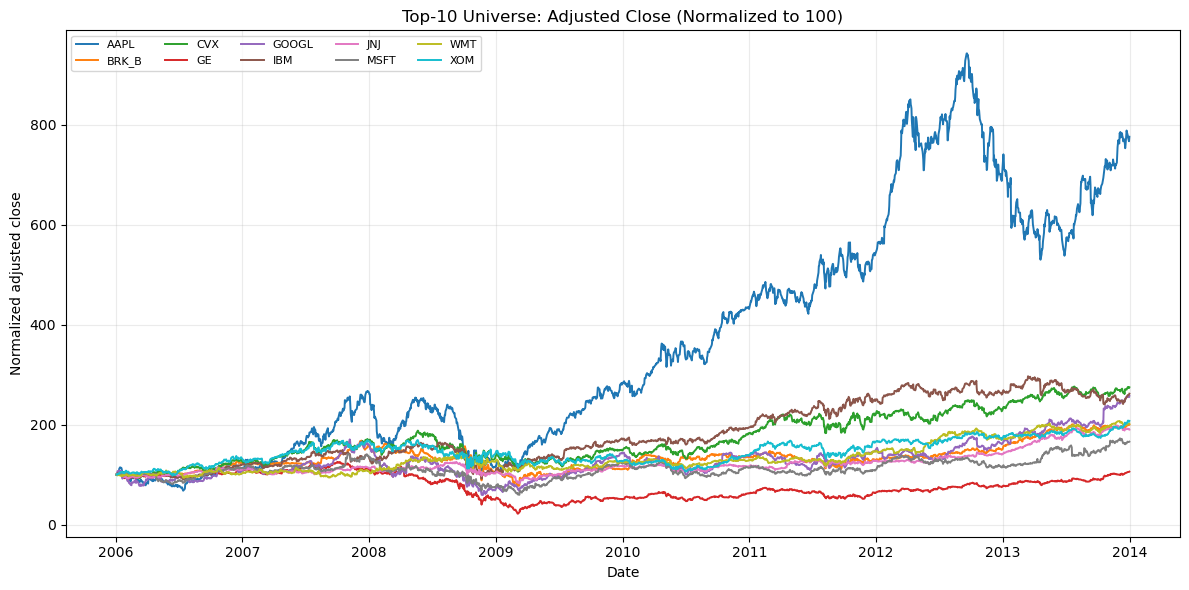

PosixPath('/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_top10_adjusted_price_paths.png')

In [12]:
plot_df = panel[["ticker", "date", "adj_close"]].dropna().copy()
plot_df = plot_df.sort_values(["ticker", "date"])

plot_df["adj_close_norm100"] = plot_df.groupby("ticker")["adj_close"].transform(
    lambda s: 100 * s / s.iloc[0] if len(s) > 0 else np.nan
)

fig, ax = plt.subplots(figsize=(12, 6))
for ticker, g in plot_df.groupby("ticker"):
    ax.plot(g["date"], g["adj_close_norm100"], label=ticker, linewidth=1.4)

ax.set_title("Top-10 Universe: Adjusted Close (Normalized to 100)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized adjusted close")
ax.legend(ncol=5, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()

fig1_path = FIG_DIR / "lstm_top10_adjusted_price_paths.png"
fig.savefig(fig1_path, dpi=140)
plt.show()

fig1_path


## Figure 2: Feature Missingness Heatmap


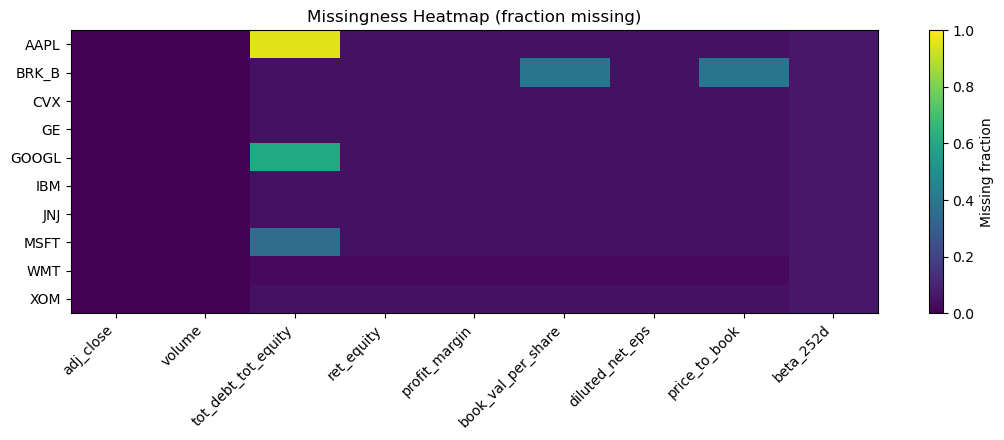

PosixPath('/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_feature_missingness_heatmap.png')

In [13]:
feature_cols = [
    "adj_close", "volume", "tot_debt_tot_equity", "ret_equity",
    "profit_margin", "book_val_per_share", "diluted_net_eps", "price_to_book", "beta_252d",
]

missing = panel.groupby("ticker")[feature_cols].apply(lambda x: x.isna().mean())

fig, ax = plt.subplots(figsize=(11, 4.5))
im = ax.imshow(missing.values, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha="right")
ax.set_yticks(range(len(missing.index)))
ax.set_yticklabels(missing.index)
ax.set_title("Missingness Heatmap (fraction missing)")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Missing fraction")
fig.tight_layout()

fig2_path = FIG_DIR / "lstm_feature_missingness_heatmap.png"
fig.savefig(fig2_path, dpi=140)
plt.show()

fig2_path


## Figure 3: Forward-Fill and No-Lookahead Diagnostic
This chart shows a single ticker (`ret_equity`) with quarter-end records, availability dates, and the daily forward-filled series used in the panel.


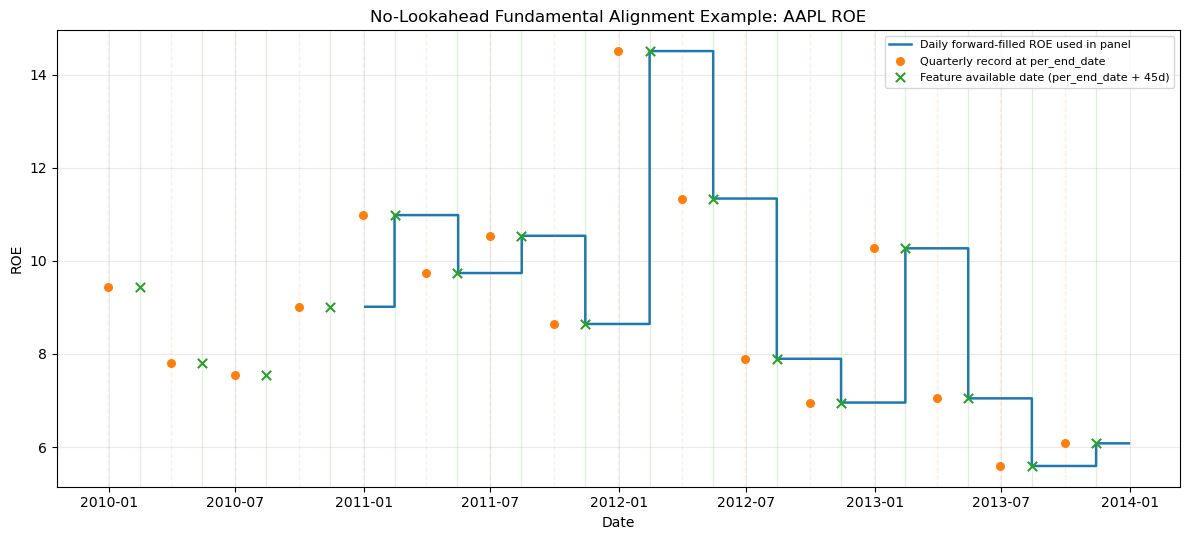

PosixPath('/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_forward_fill_no_lookahead_example.png')

In [14]:
example_ticker = top10["ticker_price"].iloc[0]

daily_ex = panel[panel["ticker"] == example_ticker][["date", "ret_equity"]].copy()
daily_ex = daily_ex[(daily_ex["date"] >= "2011-01-01") & (daily_ex["date"] <= "2013-12-31")]

fund_ex = fundamentals[fundamentals["ticker_price"] == example_ticker][
    ["per_end_date", "feature_available_date", "ret_equity"]
].copy()
fund_ex = fund_ex[(fund_ex["feature_available_date"] >= "2010-01-01") & (fund_ex["feature_available_date"] <= "2013-12-31")]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    daily_ex["date"],
    daily_ex["ret_equity"],
    drawstyle="steps-post",
    color="tab:blue",
    linewidth=1.8,
    label="Daily forward-filled ROE used in panel",
)

ax.scatter(
    fund_ex["per_end_date"],
    fund_ex["ret_equity"],
    color="tab:orange",
    marker="o",
    s=30,
    label="Quarterly record at per_end_date",
    zorder=3,
)

ax.scatter(
    fund_ex["feature_available_date"],
    fund_ex["ret_equity"],
    color="tab:green",
    marker="x",
    s=45,
    label="Feature available date (per_end_date + 45d)",
    zorder=3,
)

for d in fund_ex["per_end_date"].dropna().unique():
    ax.axvline(pd.Timestamp(d), color="tab:orange", alpha=0.12, linestyle="--", linewidth=1)
for d in fund_ex["feature_available_date"].dropna().unique():
    ax.axvline(pd.Timestamp(d), color="tab:green", alpha=0.15, linestyle="-", linewidth=1)

ax.set_title(f"No-Lookahead Fundamental Alignment Example: {example_ticker} ROE")
ax.set_xlabel("Date")
ax.set_ylabel("ROE")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="best")
fig.tight_layout()

fig3_path = FIG_DIR / "lstm_forward_fill_no_lookahead_example.png"
fig.savefig(fig3_path, dpi=140)
plt.show()

fig3_path


## Figure 4: Price Response Around Fundamental Availability Dates
This diagnostic heatmap and baseline line plot visualize how absolute daily return intensity evolves around lagged fundamental availability events.


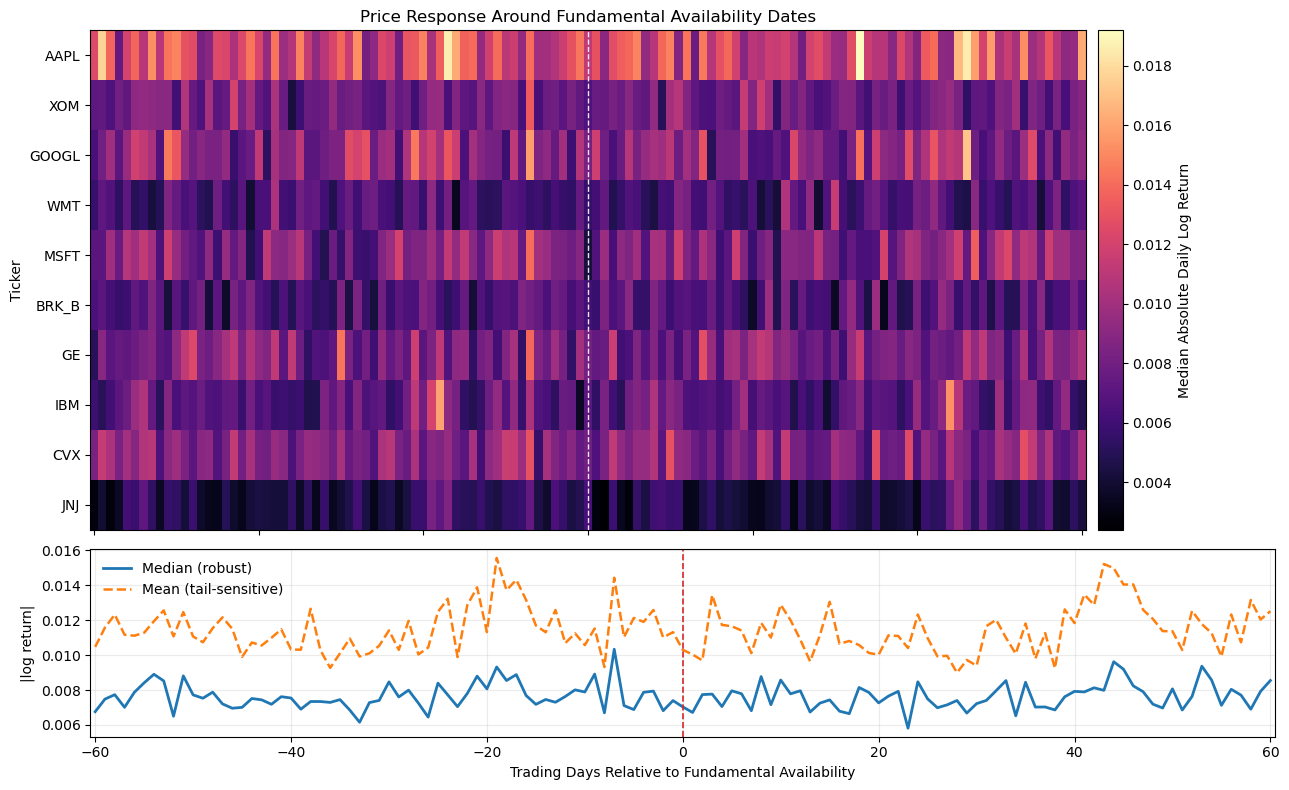

{'event_rows': 37311,
 'event_count': 320,
 'tickers': ['AAPL',
  'BRK_B',
  'CVX',
  'GE',
  'GOOGL',
  'IBM',
  'JNJ',
  'MSFT',
  'WMT',
  'XOM'],
 'window': 60,
 'figure_path': '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_fundamental_timing_vs_return_response.png'}

In [15]:
EVENT_WINDOW = 60

static_tickers = top10["ticker_price"].tolist()

# 1) Build global market calendar (prefer SPY dates if available).
global_dates = build_global_trading_calendar(prices_adj, prefer_ticker="SPY")

# 2) Build deduped fundamental availability events (changed-only enabled with safety fallback).
events_all = extract_fundamental_events(fundamentals, ticker_col="ticker_price", changed_only=True)
events = events_all[events_all["ticker"].isin(static_tickers)].copy()

# 3) Build event-time panel using global calendar anchor and event-day indexing.
price_for_events = prices_adj[prices_adj["ticker"].isin(static_tickers)].copy()
event_panel_df = build_event_time_abs_return_panel(
    prices_df=price_for_events,
    events_df=events,
    global_dates=global_dates,
    window=EVENT_WINDOW,
)

# 4) Aggregate to heatmap matrix (ticker x event_day) and overall baseline lines.
event_heatmap_df, event_baseline_series = aggregate_event_time_intensity(
    event_panel_df=event_panel_df,
    ticker_order=static_tickers,
    window=EVENT_WINDOW,
    agg="median",
)
_, event_baseline_mean_series = aggregate_event_time_intensity(
    event_panel_df=event_panel_df,
    ticker_order=static_tickers,
    window=EVENT_WINDOW,
    agg="mean",
)

# Figure: top panel heatmap, bottom panel baseline line
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    sharex=True,
)

mat = event_heatmap_df.values.astype(float)
im = ax1.imshow(
    mat,
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    extent=[-EVENT_WINDOW - 0.5, EVENT_WINDOW + 0.5, len(static_tickers) - 0.5, -0.5],
)
ax1.set_title("Price Response Around Fundamental Availability Dates")
ax1.set_ylabel("Ticker")
ax1.set_yticks(range(len(static_tickers)))
ax1.set_yticklabels(static_tickers)
ax1.axvline(0, color="white", linestyle="--", linewidth=1, alpha=0.9)
cb = fig.colorbar(im, ax=ax1, pad=0.01)
cb.set_label("Median Absolute Daily Log Return")

x = event_baseline_series.index.values
y_median = event_baseline_series.values
y_mean = event_baseline_mean_series.reindex(event_baseline_series.index).values
ax2.plot(x, y_median, color="tab:blue", linewidth=2, linestyle="-", label="Median (robust)")
ax2.plot(x, y_mean, color="tab:orange", linewidth=1.8, linestyle="--", label="Mean (tail-sensitive)")
ax2.axvline(0, color="tab:red", linestyle="--", linewidth=1.2)
ax2.set_xlabel("Trading Days Relative to Fundamental Availability")
ax2.set_ylabel("|log return|")
ax2.grid(alpha=0.25)
ax2.legend(loc="best", frameon=False)

fig.tight_layout()
fig4_path = FIG_DIR / "lstm_fundamental_timing_vs_return_response.png"
fig.savefig(fig4_path, dpi=150)
plt.show()

fig4_summary = {
    "event_rows": int(len(event_panel_df)),
    "event_count": int(events.drop_duplicates(["ticker", "feature_available_date"]).shape[0]),
    "tickers": sorted(event_panel_df["ticker"].dropna().unique().tolist()),
    "window": EVENT_WINDOW,
    "figure_path": str(fig4_path),
}
fig4_summary


This figure visualizes how the magnitude of daily returns varies around the dates when new firm fundamentals become publicly available. Rather than assuming an instantaneous price adjustment, the plot highlights that return activity is distributed over time following fundamental updates. This motivates the use of sequence-based models that can learn delayed and nonlinear responses to information, rather than relying on static or single-day signals.

Any elevated return intensity away from day 0 suggests that the market response to fundamental information can be distributed over subsequent trading days, consistent with a delayed reaction channel.


In [16]:
# Figure 4 diagnostics and hard assertions
assert not event_panel_df.empty
assert event_panel_df["event_day"].between(-EVENT_WINDOW, EVENT_WINDOW).all()
assert (event_panel_df["anchor_date"] >= event_panel_df["feature_available_date"]).all()
assert (event_panel_df["event_day"] == 0).any()
assert set(event_panel_df["ticker"].unique()).issubset(set(top10["ticker_price"]))

assert list(event_heatmap_df.columns) == list(range(-EVENT_WINDOW, EVENT_WINDOW + 1))
assert event_heatmap_df.shape[1] == 2 * EVENT_WINDOW + 1
assert event_baseline_series.index.min() == -EVENT_WINDOW
assert event_baseline_series.index.max() == EVENT_WINDOW


## Figure 5: Idiosyncratic Price Response Around Fundamental Availability
This figure repeats the event-time structure of Figure 4 using beta-hedged returns to isolate firm-specific movement around fundamental availability.


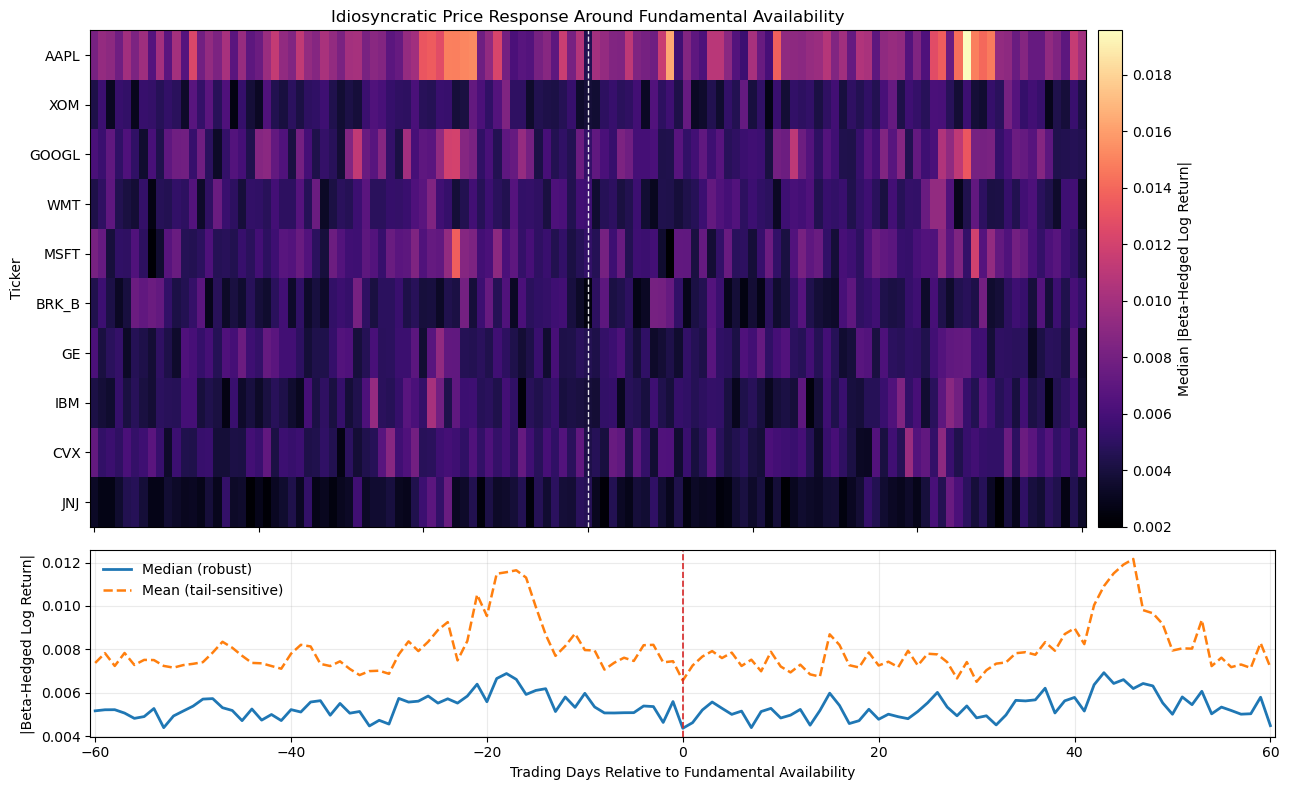

{'event_rows': 37311,
 'event_count': 320,
 'tickers': ['AAPL',
  'BRK_B',
  'CVX',
  'GE',
  'GOOGL',
  'IBM',
  'JNJ',
  'MSFT',
  'WMT',
  'XOM'],
 'window': 60,
 'figure_path': '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_fundamental_timing_vs_idiosyncratic_return.png'}

In [17]:
IDIO_EVENT_WINDOW = 60

# Rolling beta is estimated independently of the event-time analysis and reflects
# contemporaneous market exposure, not event-specific tuning.
beta_hedged_daily = build_beta_hedged_return_panel(
    prices_df=prices_adj,
    beta_df=beta_df,
    market_ticker="SPY",
)

# Reuse Figure 4 global calendar and event set.
idio_events = events.copy()
idio_events = idio_events[idio_events["ticker"].isin(static_tickers)].copy()

beta_hedged_top10 = beta_hedged_daily[beta_hedged_daily["ticker"].isin(static_tickers)].copy()

idio_event_panel_df = build_event_time_metric_panel(
    metric_df=beta_hedged_top10,
    events_df=idio_events,
    global_dates=global_dates,
    value_col="abs_idio_ret",
    window=IDIO_EVENT_WINDOW,
)

idio_heatmap_df, idio_baseline_median = aggregate_event_time_intensity(
    event_panel_df=idio_event_panel_df.rename(columns={"abs_idio_ret": "abs_log_ret"}),
    ticker_order=static_tickers,
    window=IDIO_EVENT_WINDOW,
    agg="median",
)
_, idio_baseline_mean = aggregate_event_time_intensity(
    event_panel_df=idio_event_panel_df.rename(columns={"abs_idio_ret": "abs_log_ret"}),
    ticker_order=static_tickers,
    window=IDIO_EVENT_WINDOW,
    agg="mean",
)

fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    gridspec_kw={"height_ratios": [3.2, 1.2]},
    sharex=True,
)

mat = idio_heatmap_df.values.astype(float)
im = ax1.imshow(
    mat,
    aspect="auto",
    cmap="magma",
    interpolation="nearest",
    extent=[-IDIO_EVENT_WINDOW - 0.5, IDIO_EVENT_WINDOW + 0.5, len(static_tickers) - 0.5, -0.5],
)
ax1.set_title("Idiosyncratic Price Response Around Fundamental Availability")
ax1.set_ylabel("Ticker")
ax1.set_yticks(range(len(static_tickers)))
ax1.set_yticklabels(static_tickers)
ax1.axvline(0, color="white", linestyle="--", linewidth=1, alpha=0.9)
cb = fig.colorbar(im, ax=ax1, pad=0.01)
cb.set_label("Median |Beta-Hedged Log Return|")

x = idio_baseline_median.index.values
y_med = idio_baseline_median.values
y_mean = idio_baseline_mean.reindex(idio_baseline_median.index).values
ax2.plot(x, y_med, color="tab:blue", linewidth=2, linestyle="-", label="Median (robust)")
ax2.plot(x, y_mean, color="tab:orange", linewidth=1.8, linestyle="--", label="Mean (tail-sensitive)")
ax2.axvline(0, color="tab:red", linestyle="--", linewidth=1.2)
ax2.set_xlabel("Trading Days Relative to Fundamental Availability")
ax2.set_ylabel("|Beta-Hedged Log Return|")
ax2.grid(alpha=0.25)
ax2.legend(loc="best", frameon=False)

fig.tight_layout()
fig5_path = FIG_DIR / "lstm_fundamental_timing_vs_idiosyncratic_return.png"
fig.savefig(fig5_path, dpi=150)
plt.show()

fig5_summary = {
    "event_rows": int(len(idio_event_panel_df)),
    "event_count": int(idio_events.drop_duplicates(["ticker", "feature_available_date"]).shape[0]),
    "tickers": sorted(idio_event_panel_df["ticker"].dropna().unique().tolist()),
    "window": IDIO_EVENT_WINDOW,
    "figure_path": str(fig5_path),
}
fig5_summary


Figure 5 repeats the event-time analysis using beta-hedged (idiosyncratic) returns to remove market-wide effects. The persistence of diffuse return intensity around fundamental availability after hedging suggests that the delayed response is not solely driven by broad market movements, but also reflects firm-specific dynamics. This further motivates forecasting approaches that combine lagged fundamentals with recent price dynamics rather than relying on instantaneous or market-driven signals.


In [18]:
# Figure 5 diagnostics and hard assertions
assert not idio_event_panel_df.empty
assert idio_event_panel_df["event_day"].between(-IDIO_EVENT_WINDOW, IDIO_EVENT_WINDOW).all()
assert (idio_event_panel_df["anchor_date"] >= idio_event_panel_df["feature_available_date"]).all()
assert set(idio_event_panel_df["ticker"].unique()).issubset(set(top10["ticker_price"]))

assert list(idio_heatmap_df.columns) == list(range(-IDIO_EVENT_WINDOW, IDIO_EVENT_WINDOW + 1))
assert idio_heatmap_df.shape[1] == 2 * IDIO_EVENT_WINDOW + 1

# NaN policy: abs_idio_ret can be null only when beta_252d or required returns are unavailable.
idio_daily_top10 = beta_hedged_top10.copy()
req_mask = idio_daily_top10["ticker"].isin(static_tickers)
valid_inputs = req_mask & idio_daily_top10["beta_252d"].notna() & idio_daily_top10["r_i"].notna() & idio_daily_top10["r_m"].notna()
assert idio_daily_top10.loc[valid_inputs, "abs_idio_ret"].notna().all()


## Export Processed Artifacts


In [19]:
panel_out = panel.copy().sort_values(["ticker", "date"]).reset_index(drop=True)

panel_csv = OUTPUT_DIR / "lstm_feature_panel_2006_2013.csv"
panel_out.to_csv(panel_csv, index=False)

panel_parquet = OUTPUT_DIR / "lstm_feature_panel_2006_2013.parquet"
try:
    panel_out.to_parquet(panel_parquet, index=False)
except Exception as exc:
    print(f"Parquet export skipped: {type(exc).__name__}: {exc}")

universe_csv = OUTPUT_DIR / "lstm_static_top10_universe_2012_12_31.csv"
top10.to_csv(universe_csv, index=False)

qa_files = [
    FIG_DIR / "lstm_top10_adjusted_price_paths.png",
    FIG_DIR / "lstm_feature_missingness_heatmap.png",
    FIG_DIR / "lstm_forward_fill_no_lookahead_example.png",
    FIG_DIR / "lstm_fundamental_timing_vs_return_response.png",
    FIG_DIR / "lstm_fundamental_timing_vs_idiosyncratic_return.png",
]

for f in qa_files:
    assert f.exists(), f"Missing expected figure: {f}"

export_manifest = {
    "panel_csv": str(panel_csv),
    "panel_parquet": str(panel_parquet),
    "universe_csv": str(universe_csv),
    "figures": [str(f) for f in qa_files],
    "rows": len(panel_out),
    "tickers": sorted(panel_out["ticker"].dropna().unique().tolist()),
    "split_counts": panel_out["split"].value_counts(dropna=False).to_dict(),
}
export_manifest


{'panel_csv': '/Users/assortedsphinx/Desktop/team_t/data/lstm_draft/processed/lstm_feature_panel_2006_2013.csv',
 'panel_parquet': '/Users/assortedsphinx/Desktop/team_t/data/lstm_draft/processed/lstm_feature_panel_2006_2013.parquet',
 'universe_csv': '/Users/assortedsphinx/Desktop/team_t/data/lstm_draft/processed/lstm_static_top10_universe_2012_12_31.csv',
 'figures': ['/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_top10_adjusted_price_paths.png',
  '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_feature_missingness_heatmap.png',
  '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_forward_fill_no_lookahead_example.png',
  '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_fundamental_timing_vs_return_response.png',
  '/Users/assortedsphinx/Desktop/team_t/docs/figures/lstm_fundamental_timing_vs_idiosyncratic_return.png'],
 'rows': 20130,
 'tickers': ['AAPL',
  'BRK_B',
  'CVX',
  'GE',
  'GOOGL',
  'IBM',
  'JNJ',
  'MSFT',
  'WMT',
  'XOM'],
 'split_counts':